# **Face verification system by Principal Component Analysis (PCA)**

## **The face database**
For this homework `we will work on face verification (Given a face, say whether it is person A or not)`. Face verification is quite related to face recognition (Given a face, say who it is). Face verification is a `binary classification task`, while face recognition is a multi-class problem.

In [117]:
import scipy.io
data = scipy.io.loadmat('facedata.mat')

Data is a dictionary with key value pairs. The data you want to use can be `accessed by using 'facedata' as the key`.

In [118]:
print(data['facedata'].shape)

(40, 10)


- face data is a `2-dimensional array with size 40x10`
- Each data is indexed by i and j
- where `i is the person index`
- `j is the index of the pose`
- In other words, there are 40 people in the database.

[[48 46 50 ... 50 54 53]
 [47 47 48 ... 37 46 50]
 [46 48 43 ... 33 41 51]
 ...
 [49 49 50 ... 45 46 47]
 [48 48 49 ... 45 46 46]
 [51 48 50 ... 45 45 46]]
(56, 46)


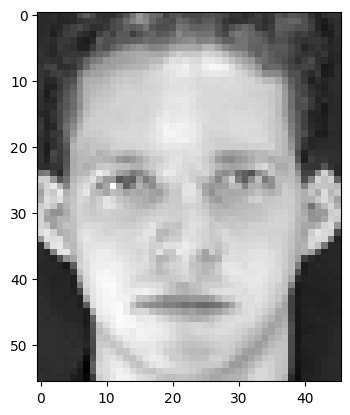

In [119]:
# There are 10 images per person.
print(data['facedata'][0,0])

# Each image is a 56 by 46 image
print(data['facedata'][0,0].shape)

# You can see the image by using the imshow in matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
plt.imshow(data['facedata'][0,0],cmap="gray")
plt.show()

## **Working with images**
Each pixel in an image is usually represented by a 8-bit unsigned integer (values from 0 to 255). In order to easily work on images, we usually convert them to floats or doubles using the following command.

In [120]:
from skimage import img_as_float
xf = {}
xf[0,0] = img_as_float(data['facedata'][0,0])
print(xf[0,0])

[[0.18823529 0.18039216 0.19607843 ... 0.19607843 0.21176471 0.20784314]
 [0.18431373 0.18431373 0.18823529 ... 0.14509804 0.18039216 0.19607843]
 [0.18039216 0.18823529 0.16862745 ... 0.12941176 0.16078431 0.2       ]
 ...
 [0.19215686 0.19215686 0.19607843 ... 0.17647059 0.18039216 0.18431373]
 [0.18823529 0.18823529 0.19215686 ... 0.17647059 0.18039216 0.18039216]
 [0.2        0.18823529 0.19607843 ... 0.17647059 0.17647059 0.18039216]]


'img_as_float' scales 0-255 to 0-1. You can still show the image using the same 'imshow' command.

Note that the index of a 2D image starts from the upper left corner of the image. `The first dimension goes downwards, while the second dimension goes to the right (think of it as a matrix).` To understand what this means, try the following code.

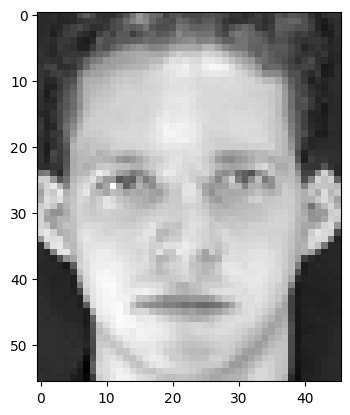

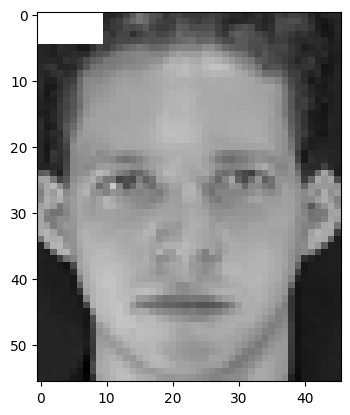

In [121]:
plt.imshow(xf[0,0],cmap="gray")
plt.show()

x_temp = xf[0,0].copy()
x_temp[0:5,0:10] = 1 # In float format, 1 is white

plt.imshow(x_temp,cmap="gray")
plt.show()

## **The similarity matrix**

Consider a set of N data points, `a similarity matrix S` is a matrix where `S_{i,j} is the distance between the ith and the jth data point.` A similarity matrix can be very useful for analyzing the data and its distribution. Since a similarity matrix can also be considered as an image, you can also show it as an image to see the pattern in the data.

But how do we define similarity? How can we quantify whether image A is closer to B than image C? One way is to treat each pixel in image as an element in a vector (you may find the function 'numpy.reshape()' useful). Then, compare the two vectors using Euclidean distance.

Euclidean distance between vector x and y is defined as:
$$
Euclidean\_dis = \sqrt{\sum_d (x_d - y_d)^2}
$$
where d refers to the index of the dimension.

### **1. What is the Euclidean distance between xf[0,0] and xf[0,1]? What is the Euclidean distance between xf[0,0] and xf[1,0]? Does the numbers make sense? Do you think these numbers will be useful for face verification? Why?** *(3 points)*

In [122]:
xf = {}
for i in range(40):
    for j in range(10):
        xf[i,j] = img_as_float(data['facedata'][i,j])



### **Visualize all 40x10 faces in the dataset**

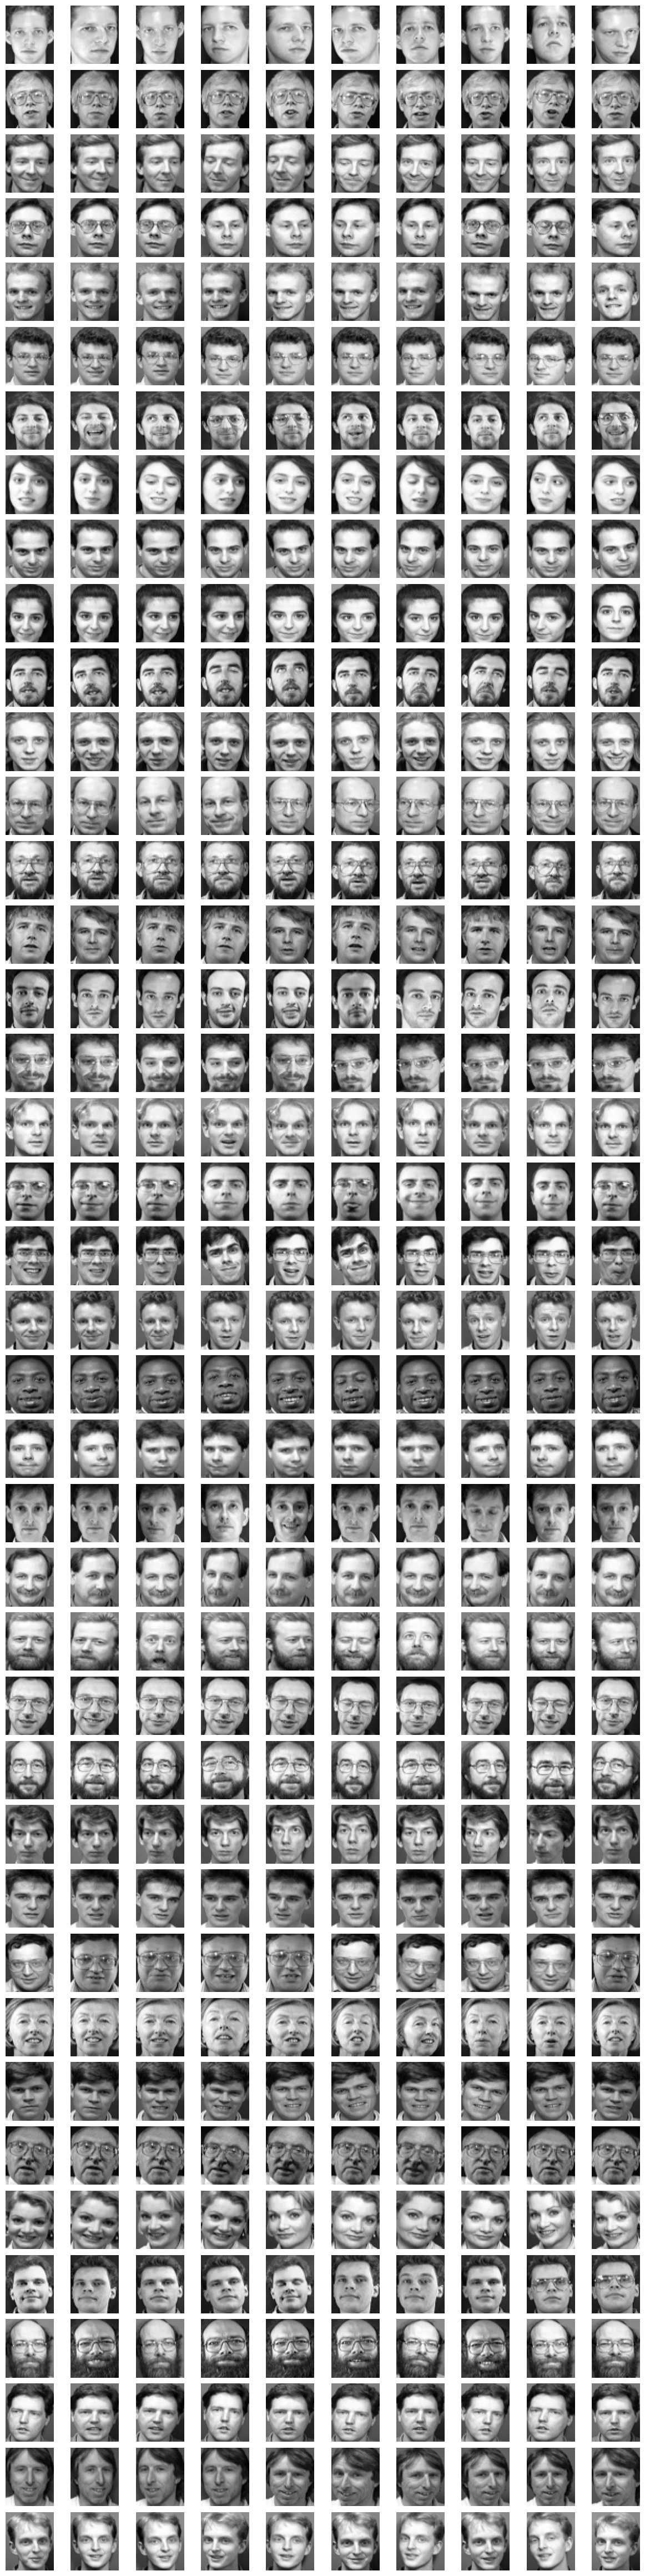

In [ ]:
import matplotlib.pyplot as plt

# Create a 40x10 grid of subplots
fig, axes = plt.subplots(40, 10, figsize=(15, 60))
fig.subplots_adjust(wspace=0.1, hspace=0.1)

for i in range(40):
    for j in range(10):
        axes[i, j].imshow(xf[i, j], cmap='gray')
        axes[i, j].axis('off')

plt.show()


xf[0,0]


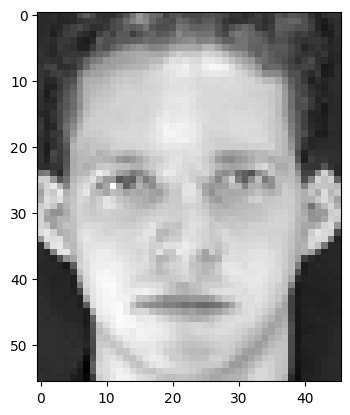

xf[0,1]


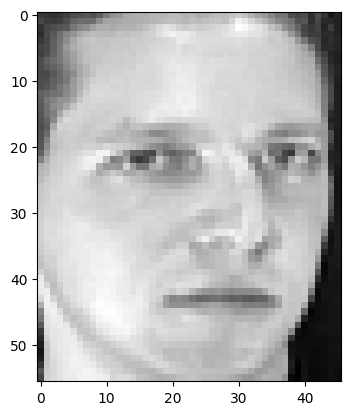

xf[1,0]


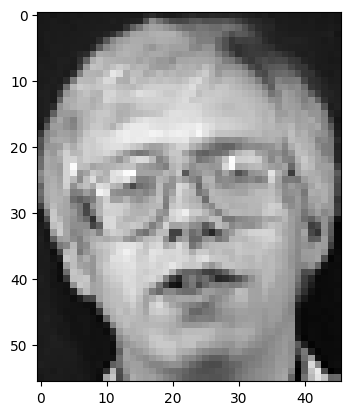

In [123]:
print("xf[0,0]")
plt.imshow(xf[0,0],cmap="gray")
plt.show()

print("xf[0,1]")
plt.imshow(xf[0,1],cmap="gray")
plt.show()

print("xf[1,0]")
plt.imshow(xf[1,0],cmap="gray")
plt.show()

In [124]:
import numpy as np

def euclidean_distance(img1, img2):
    return np.sqrt(np.sum((img1.flatten() - img2.flatten())**2))

dist_00_01 = euclidean_distance(xf[0,0], xf[0,1])
dist_00_10 = euclidean_distance(xf[0,0], xf[1,0])

print(f"Distance between xf[0,0] and xf[0,1]: {dist_00_01:.4f}")
print(f"Distance between xf[0,0] and xf[1,0]: {dist_00_10:.4f}")


Distance between xf[0,0] and xf[0,1]: 10.0376
Distance between xf[0,0] and xf[1,0]: 8.1733


#### **Answer**
These numbers will not be useful for face verification because it calculate pixel by pixel that if people are facing the same direction, they are more likely to get this value.

---

As we continue our exercise, we will refine our feature vectors so that the Euclidean distance between two images can be used in a face verification system. We define the similarity matrix, $A$, as a matrix whose elements $A_{i,j}$ is the Euclidean distance between data sample $i$ from list $T$ and data sample $j$ from list $D$, where list $T,D$ are lists of data samples.

### **2. Write a function that takes in a set of feature vectors T and a set of feature vectors D, and then output the similarity matrix A. Show the matrix as an image. Use the feature vectors from the first 3 images from all 40 people for list T (in order x[0, 0], x[0, 1], x[0, 2], x[1, 0], x[1, 1], ...x[39, 2]). Use the feature vectors from the remaining 7 images from all 40 people for list D (in order x[0, 3], x[0, 4], x[0, 5], x[1, 6], x[0, 7], x[0, 8], x[0, 9], x[1, 3], x[1, 4]...x[39, 9]). We will treat T as our training images and D as our testing images.** *(5 points)*

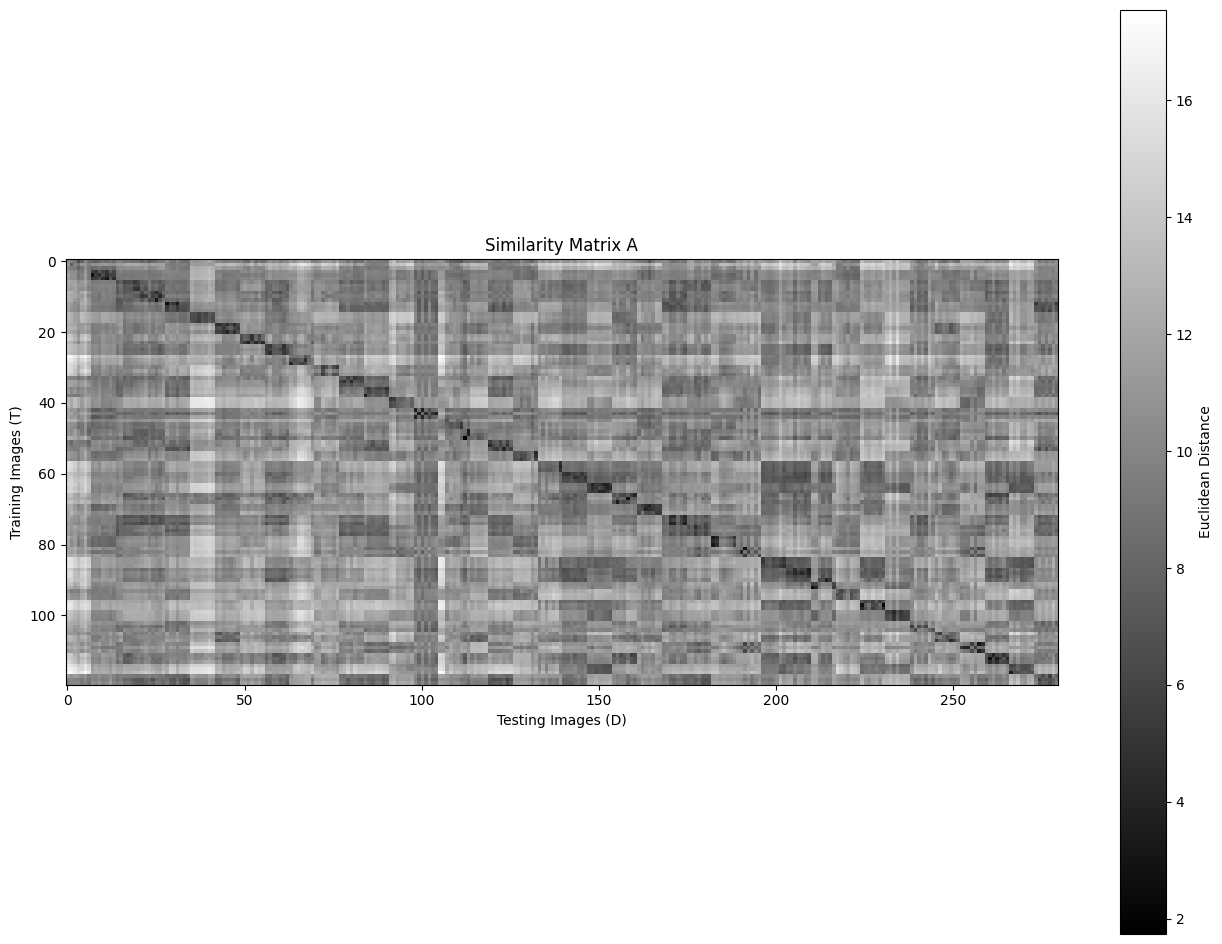

In [125]:
def calculate_similarity_matrix(T, D):
    A = np.zeros((len(T), len(D)))
    for i in range(len(T)):
        for j in range(len(D)):
            A[i,j] = euclidean_distance(T[i], D[j])
    return A

# Create list T (first 3 images from all 40 people)
T = []
for i in range(40):
    for j in range(3):
        T.append(xf[i,j])
        
# Create list D (remaining 7 images from all 40 people)
D = []
for i in range(40):
    for j in range(3, 10):
        D.append(xf[i,j])

A = calculate_similarity_matrix(T, D)

# import matplotlib.pyplot as plt
plt.figure(figsize=(16, 12))
plt.imshow(A, cmap='gray')
plt.colorbar(label='Euclidean Distance')
plt.title('Similarity Matrix A')
plt.xlabel('Testing Images (D)')
plt.ylabel('Training Images (T)')
plt.show()


In our simple face verification system, given a test image, we want to test if that image comes from person A or not. We will compare the test image against the three training images from person A we have. `If the minimum distance (between the three training images) is below a threshold,` $t$, `we say that the test image is person A.`

---

### **3. Write a function that takes in the similarity matrix created from the previous part, and a threshold t as inputs. The outputs of the function are the true positive rate and the false alarm rate of the face verification task (280 Test images, tested on 40 people). What is the true positive rate and the false alarm rate for t = 10?** *(5 points)*

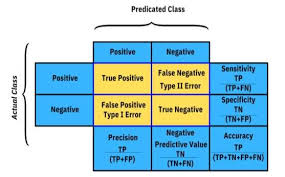

In [126]:
def calculate_rates(A, t):
    TP = 0
    FP = 0
    total_positives = 40 * 3 * 7  # 840 positive pairs # (7 test with 3 first image = 21 combination) * 40 people
    total_negatives = 120 * 280 - total_positives  # 32760 negative pairs # [(3 first image * 40 people) * (7 test * 40 people)] - total_positives
    
    for i in range(120):  # Index in T
        for j in range(280):  # Index in D
            # Person index for T: i // 3
            # Person index for D: j // 7
            true_match = (i // 3) == (j // 7) # check that is the same person
            predict_match = A[i, j] <= t # predict that is match
            
            if predict_match:
                if true_match:
                    TP += 1
                else:
                    FP += 1
                    
    TPR = TP / total_positives
    FAR = FP / total_negatives
    return TPR, FAR

TPR, FAR = calculate_rates(A, 10)
print(f"For t = 10, True Positive Rate: {TPR:.4f}")
print(f"For t = 10, False Alarm Rate: {FAR:.4f}")


For t = 10, True Positive Rate: 0.9714
For t = 10, False Alarm Rate: 0.3547


---

### **4. Plot the RoC curve (curve between the true positive rate (TP) as y-axis and the false alarm rate (false positive rate or FP) as x-axis) for this simple verification system when threshold changes. What should be the minimum threshold to generate the RoC curve? What should be the maximum threshold? Your RoC should be generated from at least 1000 threshold levels equally spaced between the minimum and the maximum. (You should write a function for this).** *(5 points)*

Minimum Threshold: 1.7420
Maximum Threshold: 17.5417


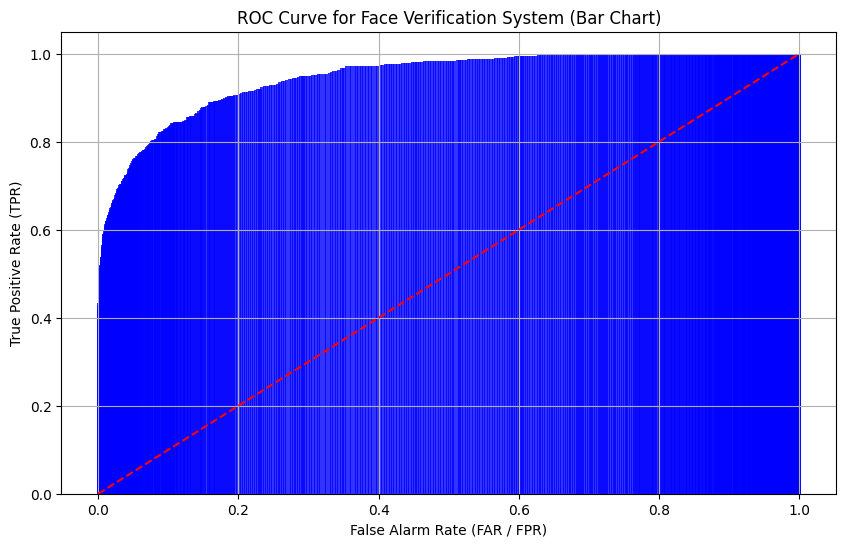

In [ ]:
def plot_roc_curve(A):
    # Minimum and maximum thresholds based on the similarity matrix values
    min_threshold = np.min(A)
    max_threshold = np.max(A)
    print(f"Minimum Threshold: {min_threshold:.4f}")
    print(f"Maximum Threshold: {max_threshold:.4f}")
    
    # Generate 1000 evenly spaced threshold levels
    thresholds = np.linspace(min_threshold, max_threshold, 1000)
    
    tpr_list = []
    far_list = []
    
    # Precompute true matches to optimize metric calculation
    total_positives = 40 * 3 * 7
    total_negatives = 120 * 280 - total_positives
    
    true_match_matrix = np.zeros_like(A, dtype=bool)
    for i in range(120):
        for j in range(280):
            if (i // 3) == (j // 7):
                true_match_matrix[i, j] = True
                
    for t in thresholds:
        predict_match_matrix = A <= t
        
        TP = np.sum(predict_match_matrix & true_match_matrix)
        FP = np.sum(predict_match_matrix & ~true_match_matrix)
        
        tpr_list.append(TP / total_positives)
        far_list.append(FP / total_negatives)
        
    # Plot the ROC curve as a bar chart
    plt.figure(figsize=(10, 6))
    plt.bar(far_list, tpr_list, width=0.005, alpha=0.8, color='blue')
    plt.plot([0, 1], [0, 1], 'r--')  # Diagonal line for random chance
    plt.xlabel('False Alarm Rate (FAR / FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curve for Face Verification System (Bar Chart)')
    plt.grid(True)
    plt.show()

plot_roc_curve(A)


---

## **Principle Component Analysis (PCA)**

PCA is a method for dimensionality reduction that is very flexible and fits many use cases. It is unsupervised (needs no class label). The core of `PCA is using eigen decomposition to decompose the data into the directions of maximum variance.` Let’s define a matrix X with each column as an input sample $x_i$.

A typical PCA starts by normalizing each feature dimension so that they have equal range. For our case, since our input vectors are already between 0 and 1, we can skip this step. `The first step of PCA is to first remove the global mean from our data.` Let $μ_x$ be the means of the input data along each input dimension. Let $X̂$ be the matrix with the mean of the input samples removed. Be sure to use the mean computed from just the training examples.

### **5. Compute the mean vector from the training images. Show the vector as an image (use 'numpy.reshape()'). This is typically called the meanface (or meanvoice for speech signals). And plot the meanface by 'imshow' command.** *(2 points)*

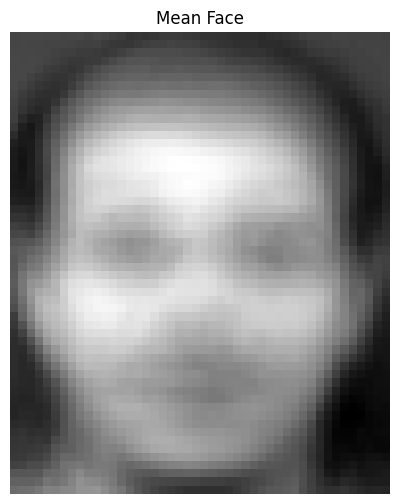

In [128]:
# Convert training images to 1D vectors
T_vectors = [img.flatten() for img in T]

# Compute the mean vector across all training images
mean_vector = np.mean(T_vectors, axis=0)

# Reshape the mean vector back into the original image dimensions (56x46)
meanface = np.reshape(mean_vector, (56, 46))

# Plot the meanface
plt.figure(figsize=(5, 6))
plt.imshow(meanface, cmap='gray')
plt.title('Mean Face')
plt.axis('off')
plt.show()


---

### **6. What is the size of the covariance matrix? What is the rank of the covariance matrix?** *(2 points)*

#### **Answer**

- **Size of the covariance matrix**: Since each image has dimensions $56 \times 46$, flattening them results in a feature vector of length $D = 56 \times 46 = 2576$. Therefore, the overall size of the covariance matrix is **$2576 \times 2576$**.
- **Rank of the covariance matrix**: For a set of $N$ data samples, the mathematically guaranteed maximum rank of their resulting sample covariance matrix is bounded by $N - 1$. Since there are exactly $N = 120$ images in our training set (3 training images each from 40 uniquely distinct people), the rank of this covariance matrix is at most **$120 - 1 = 119$**.

---

The trick is to compute the Gram Matrix $(X̂^TX̂)$, which is the inner product between the input matrices.

### **7. What is the size of the Gram matrix? What is the rank of Gram matrix? If we compute the eigenvalues from the Gram matrix, how many non-zero eigenvalues do we expect to get?** *(3 points)*

- **Size of the Gram matrix**: For $N$ training samples, the Gram matrix is constructed computationally as an inner product of the centralized dataset matrix. Its dimensions correspond solely to the number of samples, independent of the feature count, yielding an overall size of $N \times N = 120 \times 120$.
- **Rank of the Gram matrix**: The theoretical non-zero rank matches the covariance matrix constraint. Assuming the typical step where the images are centered to their mean for PCA, the maximum rank falls precisely at $N - 1 = 119$.
- **Number of non-zero eigenvalues**: Because the rank of this Gram matrix is bounded to 119, we predictably expect to get at most 119 non-zero eigenvalues from its decomposition.

---

### **8. Is the Gram matrix also symmetric? Why?** *(2 points)*

Yes, the Gram matrix is naturally and inherently symmetric. The Gram matrix $K$ is built by taking computing the inner products between pairs of the dataset vectors, and its fundamental linear algebra definition is $K = X^T X$ (where matrix $X$ possesses the $N$ sample columns of $D$ features). Following the rule of transposing matrix operations, evaluating the transpose of the Gram matrix gives $K^T = (X^T X)^T = X^T (X^T)^T = X^T X = K$. Thus, $K^T = K$, guaranteeing strict structural symmetry!

Intuitively, any element $K_{i,j}$ describes the simple dot-product sequence of sample $i$ applied against sample $j$ ($\langle x_i, x_j \rangle$). Due to the commutativity characteristic of dot products over real field numbers, this returns the exact same scalar value as measuring sample $j$ against sample $i$ ($\langle x_j, x_i \rangle = K_{j,i}$).

---

Using the gram matrix, we instead solve for the eigenvector, $\mathbf{v}'$.

$$\hat{X}^T \hat{X} \mathbf{v}' = \lambda \mathbf{v}'$$

where the desired eigenvector (eigenvector of the covariance matrix) can be computed from $\mathbf{v}'$ (eigenvector of the gram matrix) using the following relationship

$$\mathbf{v} = \hat{X} \mathbf{v}'$$

In order to compute the eigenvectors and eigenvalues, we can use the function 'numpy.linalg.eigh' which can be used on symmetric matrices. For symmetric matrices, the eigenvectors and eigenvalues will always be real. In contrast, if the matrix is not symmetric, we have to use the function 'numpy.linalg.eig' which will output complex numbers.

### **9. Compute the eigenvectors and eigenvalues of the Gram matrix, $\mathbf{v}'$ and $λ$. Sort the eigenvalues and eigenvectors in descending order so that the first eigenvalue is the highest, and the first eigenvector corresponds to the best direction. How many non-zero eigenvalues are there? If you see a very small value, it is just numerical error and should be treated as zero.** *(5 points)*

In [129]:
# Center the data by subtracting the mean vector
X_centered = T_vectors - mean_vector

# Compute the Gram matrix K = X_centered @ X_centered.T (size 120x120)
K = np.dot(X_centered, X_centered.T)

# Compute eigenvalues (lambda) and eigenvectors (v') of the symmetric Gram matrix
eigenvalues, eigenvectors = np.linalg.eigh(K)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Determine the number of non-zero eigenvalues
tolerance = 1e-2
non_zero_count = np.sum(eigenvalues > tolerance)

print(f"Number of non-zero eigenvalues (> {tolerance}): {non_zero_count}")


[ 1.42392971e+03  8.75375177e+02  5.58624400e+02  4.07347157e+02
  3.71021274e+02  2.63280801e+02  2.03396990e+02  1.90965101e+02
  1.66548056e+02  1.43570551e+02  1.22951200e+02  1.04788229e+02
  9.36606993e+01  8.52020934e+01  8.00790884e+01  7.22926270e+01
  6.92896016e+01  6.55557914e+01  6.16791259e+01  5.90743553e+01
  5.42659430e+01  5.19180210e+01  4.60439029e+01  4.49517564e+01
  4.38154370e+01  4.17882938e+01  4.04839086e+01  3.80160594e+01
  3.72939497e+01  3.42784031e+01  3.38082909e+01  3.24110643e+01
  3.01160763e+01  2.88090967e+01  2.76934934e+01  2.72362796e+01
  2.63193795e+01  2.55181270e+01  2.42531018e+01  2.33566654e+01
  2.24888684e+01  2.22128871e+01  2.13271981e+01  2.05964187e+01
  1.97567698e+01  1.91068901e+01  1.86898335e+01  1.81386227e+01
  1.79801629e+01  1.69617092e+01  1.63867949e+01  1.56952212e+01
  1.56409226e+01  1.50995911e+01  1.45534702e+01  1.38473352e+01
  1.37682769e+01  1.35139271e+01  1.31342609e+01  1.26436508e+01
  1.25449028e+01  1.22504

---

### **10. Plot the eigenvalues. Observe how fast the eigenvalues decrease. In class, we learned that the eigenvalues are the size of the variance for each eigenvector direction. If I want to keep 95% of the variance in the data, how many eigenvectors should I use? The plot example is shown below.** *(5 points)*

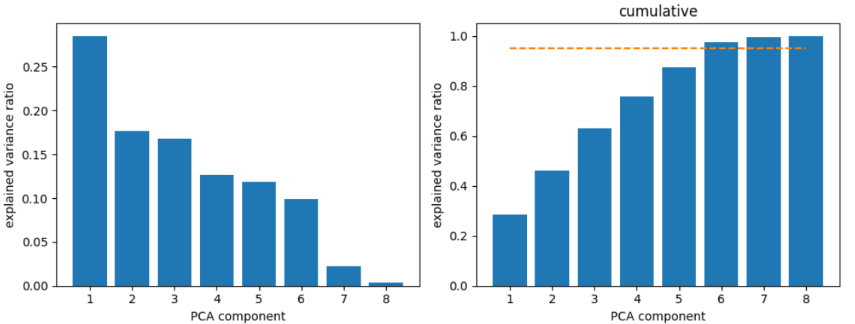

Explained Variance Ratio ($ER$):

$$ER_i = \frac{\lambda_i}{\sum_{j=1}^{n} \lambda_j}$$

- $\lambda_i$: Eigenvalue of Component $i$
- $\sum \lambda_j$: summation of all Eigenvalues (= Total Variance of data)

Number of eigenvectors to retain >= 95% of variance: 64


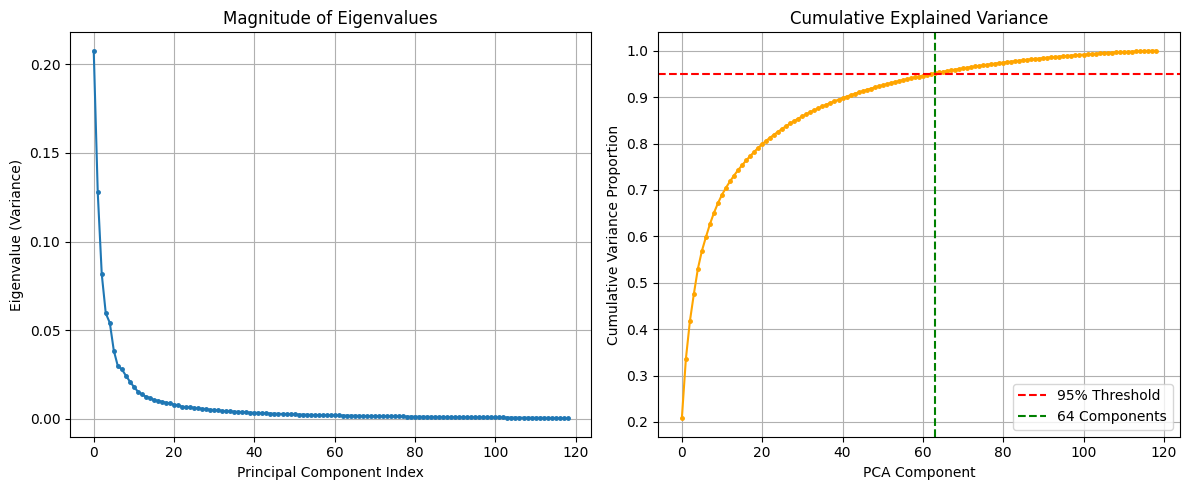

In [130]:
# Filter to only use the non-zero eigenvalues (we found 119 earlier)
valid_eigenvalues = eigenvalues[eigenvalues > tolerance]

# Compute the cumulative explained variance percentage
total_variance = np.sum(valid_eigenvalues)
variance_ratio = valid_eigenvalues / total_variance
cumulative_variance = np.cumsum(valid_eigenvalues) / total_variance

# Find the minimum number of components to reach at least 95% variance
num_components_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1
print(f"Number of eigenvectors to retain >= 95% of variance: {num_components_95}")

plt.figure(figsize=(12, 5))

# Subplot 1: Plot of Eigenvalues
plt.subplot(1, 2, 1)
plt.plot(variance_ratio, marker='.', linestyle='-', markersize=5)
plt.title('Magnitude of Eigenvalues')
plt.xlabel('Principal Component Index')
plt.ylabel('Eigenvalue (Variance)')
plt.grid(True)

# Subplot 2: Cumulative Variance
plt.subplot(1, 2, 2)
plt.plot(cumulative_variance, marker='.', linestyle='-', markersize=5, color='orange')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.axvline(x=num_components_95 - 1, color='g', linestyle='--', label=f'{num_components_95} Components')
plt.title('Cumulative Explained Variance')
plt.xlabel('PCA Component')
plt.ylabel('Cumulative Variance Proportion')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


---

### **11. Compute "v" and show the first 10 eigenvectors as images of the original "v" and "v" taking renormalize and show the norm of each vector. Two example eigenvectors are shown below. We call these images eigenfaces (or eigenvoice for speech signals).** *(4 points)*

(2576, 120)


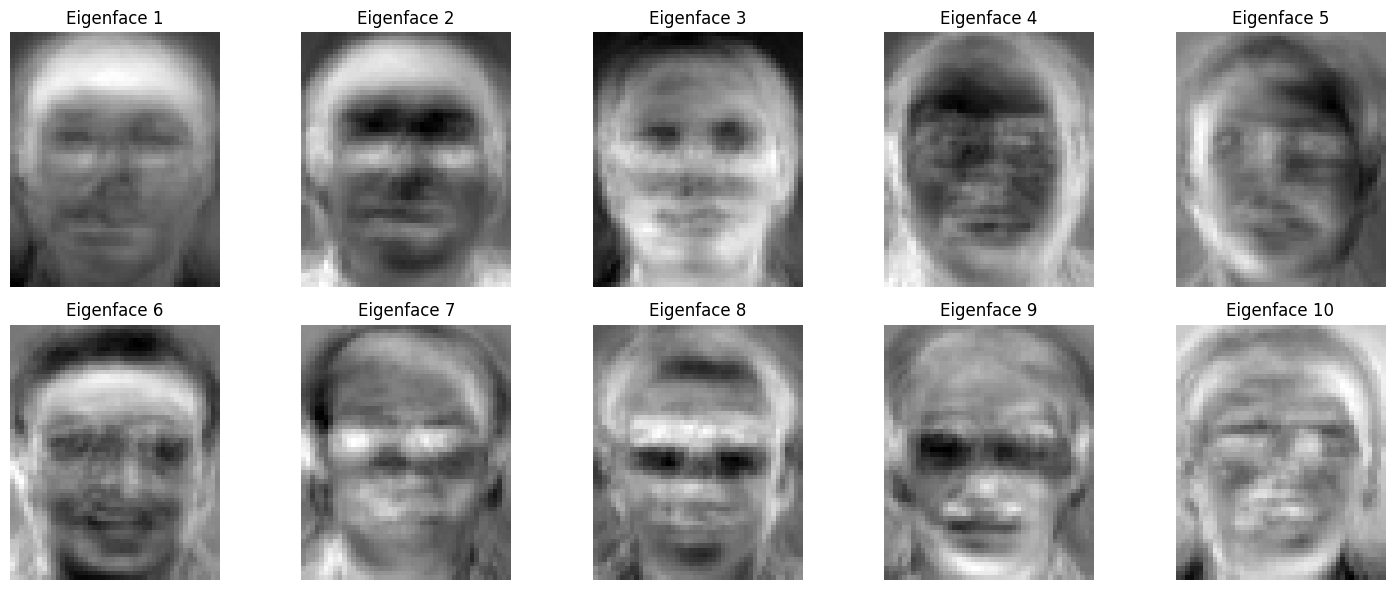

In [131]:
# Compute original eigenvectors v from Gram matrix eigenvectors (V_prime) 
# X_centered has shape (120, 2576), we need X_centered.T @ V_prime
V_original = np.dot(X_centered.T, eigenvectors)
V_renorm = np.zeros_like(V_original)

print(V_renorm.shape)

plt.figure(figsize=(15, 6))

for i in range(10):
    v_orig = V_original[:, i]
    norm_orig = np.linalg.norm(v_orig)
    
    # Renormalize to ensure the vector has unit length
    v_renorm = v_orig / norm_orig
    V_renorm[:, i] = v_renorm
    
    # norm_renorm = np.linalg.norm(v_renorm)
    # print(f"Eigenvector {i+1}: Original Norm = {norm_orig:.4f}, Renormalized Norm = {norm_renorm:.4f}")
    
    # Reshape the 2576-D vector back to 56x46 and plot the eigenface
    img_eigenface = np.reshape(v_renorm, (56, 46))

    # print(f"Eigen {i+1}: {img_eigenface}")
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img_eigenface, cmap='gray')
    plt.title(f"Eigenface {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()


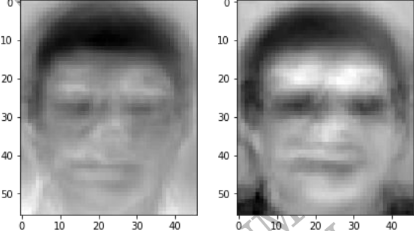

---

### **12. From the image, what do you think the first eigenvector captures? What about the second eigenvector? Look at the original images, do you think biggest variance are capture in these two eigenvectors?** *(3 points)*

#### **Answer**

1. **First Eigenvector**: The first eigenface typically captures the single most profound source of variation across all original images. For standard face datasets, this nearly always corresponds to **global illumination/lighting variations** (such as a left-to-right lighting gradient) or the broad overarching outline of the average person's head against the background.
2. **Second Eigenvector**: The second eigenface captures the second largest source of geometric variation. This inherently models features orthogonal to the first component, which usually manifests as **vertical illumination differences** (top-to-bottom shading) or broad structural **head pose tendencies** (e.g., the subject looking slightly left/right or tilting their chin).
3. **Biggest Variance**: **Yes, absolutely.** PCA mathematically dictates this behavior by its very definition. Because the eigenvectors are extracted and explicitly sorted by the magnitude of their corresponding eigenvalues in descending sequence, the first two eigenfaces represent the axes of maximal pixel-level variance across the entire image database.

---

## **PCA subspace and the face verification system**

These eigenfaces we computed serve as good directions to project our data onto in order to decrease the number of dimensions. Since we have shown in class that these eigenvectors are orthogonal (and we normalized them so that they are orthonormal), we can find the projection, $\mathbf p$, of the data onto the eigenface subspace by

$$\mathbf{p} = V^T (\mathbf{x} - \boldsymbol{\mu}_{\mathbf{x}})$$

where $V$ is a matrix whose columns are the eigenvectors, $\mathbf v$. The projection values, $\mathbf p$, will serve as our new input features.

### **13. Find the projection values of all images. Keep the first k = 10 projection values. Repeat the simple face verification system (like item 5 in CHAPTER02) we did earlier using these projected values.** *(5 points)*

120 10
Evaluating Verification System using k=10 PCA Projections...
Minimum Threshold: 0.2803
Maximum Threshold: 15.8204


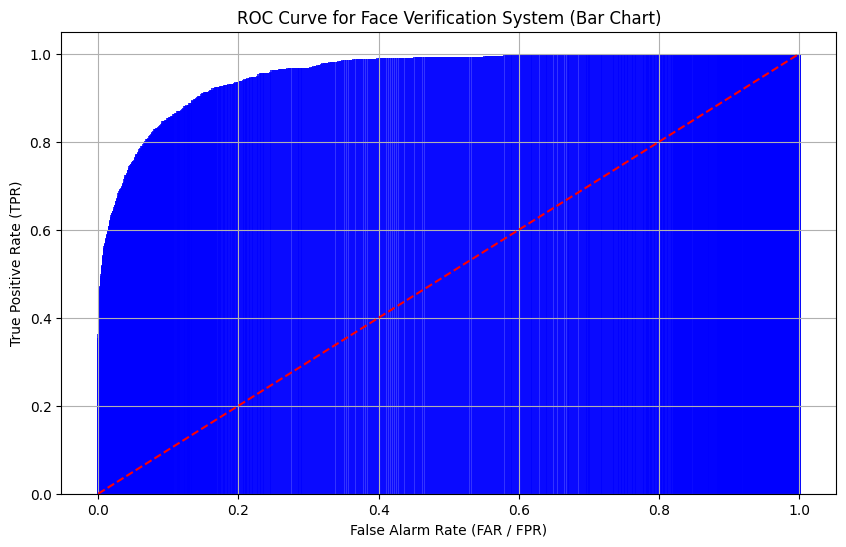

In [189]:
# Select the top k=10 renormalized eigenvectors
k = 10
V_k = V_renorm[:, :k]  # Shape: (2576, 10)

# Function to project a list of image vectors onto the top k eigenvectors
def project_images(image_list, mean_vec, V_subspace):
    proj_list = []
    for img in image_list:
        img_centered = img.flatten() - mean_vec
        proj = np.dot(img_centered, V_subspace)
        proj_list.append(proj)
    return proj_list

# print(len(T), len(T[0]), len(T[0][0]), mean_vector.shape, V_k.shape)
# 1. Find projection values (k=10) for Training (T) and Testing (D) images
T_proj = project_images(T, mean_vector, V_k)
D_proj = project_images(D, mean_vector, V_k)
print(len(T_proj), len(T_proj[0]))

# 2. Compute the new similarity matrix A_proj using projected values
A_proj = np.zeros((len(T_proj), len(D_proj)))
for i in range(len(T_proj)):
    for j in range(len(D_proj)):
        A_proj[i, j] = np.linalg.norm(T_proj[i] - D_proj[j])

# plt.figure(figsize=(10, 8))
# plt.imshow(A_proj, cmap='gray')
# plt.colorbar(label='Euclidean Distance (k=10 PCA Subspace)')
# plt.title('Similarity Matrix A_proj (Projected Data)')
# plt.xlabel('Testing Images (D)')
# plt.ylabel('Training Images (T)')
# plt.show()

# 3. Repeat the face verification system performance evaluating via ROC Curve
print("Evaluating Verification System using k=10 PCA Projections...")
plot_roc_curve(A_proj)


---

One of the usage for PCA is compression. Using the project values, we can reconstruct the original image. This can be done by

$$\mathbf{x}' = \boldsymbol{\mu}_{\mathbf{x}} + V \mathbf{p}$$

where $\mathbf{x}'$ is the reconstructed image.

We can compute the error from such reconstruction by computing the Mean Square Error (MSE)

$$MSE = \frac{1}{N} \sum_{i=1}^{N} (x_i - \hat{x}_i)^2$$

where $N$ is the dimension of the original input.

### **14. Reconstruct the first image using this procedure. Use k = 10, what is the MSE?** *(5 points)*

(2576, 10)
Mean Squared Error (MSE) of first image reconstruction using k=10: 0.006148


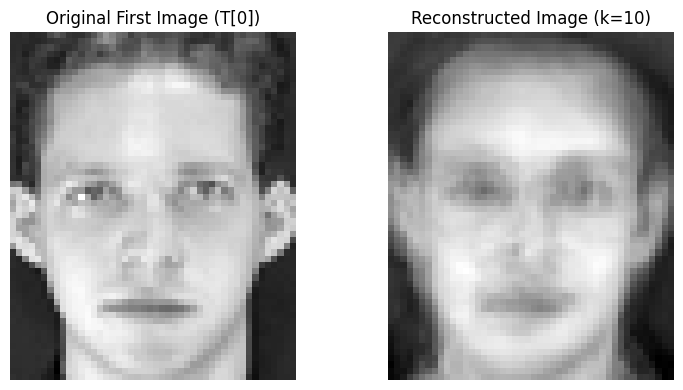

In [ ]:
# The first image in the training set
img_orig = T[0].flatten()

# Projection values for the first image using k=10 are already calculated in T_proj[0]
proj_val = T_proj[0]

# print(V_k.shape)
# Reconstruct the centered image representation
img_reconst_centered = np.dot(proj_val, V_k.T)

# Add the mean vector back to retrieve original space mapping
img_reconst = img_reconst_centered + mean_vector

# Compute Mean Squared Error (MSE)
mse = np.mean((img_orig - img_reconst) ** 2)
print(f"Mean Squared Error (MSE) of first image reconstruction using k=10: {mse:.6f}")

# Visualize Original against the Reconstructed version
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(np.reshape(img_orig, (56, 46)), cmap='gray')
plt.title("Original First Image (T[0])")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.reshape(img_reconst, (56, 46)), cmap='gray')
plt.title("Reconstructed Image (k=10)")
plt.axis('off')

plt.tight_layout()
plt.show()

---